# ST-GNN 실험 결과 분석

`checkpoints/` 하위의 모든 `metrics.json`을 자동 수집해 비교합니다.

**분석 구성**
1. 전체 결과 로드 & 요약 테이블
2. 윈도우별 MAE/RMSE 히트맵 (scenario × graph_mode)
3. 시나리오별 최고 성능 (Best across all windows/modes)
4. 그래프 모드별 성능 비교
5. 윈도우 크기 효과 분석
6. 학습 Loss Curve (선택 실험)
7. 전체 랭킹 테이블

In [16]:
import json
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
CHECKPOINT_ROOT = "checkpoints"

# ── metrics.json 전부 수집 ──────────────────────────────────────────────────
records = []
for path in glob.glob(os.path.join(CHECKPOINT_ROOT, "**", "metrics.json"), recursive=True):
    with open(path) as f:
        rec = json.load(f)
    rec["path"] = os.path.dirname(path)
    records.append(rec)

df = pd.DataFrame(records)
df["window"]     = df["window"].astype(int)
df["graph_mode"] = df["graph_mode"].astype("category")

# 시나리오 번호 순 정렬용 키
df["s_num"] = df["scenario"].str.extract(r"S(\d+)_").astype(int)
df = df.sort_values(["window", "s_num", "graph_mode"]).reset_index(drop=True)

print(f"총 {len(df)}개 실험 결과 로드")
print(f"윈도우: {sorted(df['window'].unique())}")
print(f"시나리오: {sorted(df['scenario'].unique())}")
print(f"그래프 모드: {list(df['graph_mode'].cat.categories)}")

총 37개 실험 결과 로드
윈도우: [12, 24, 48]
시나리오: ['S1_transport_pm10', 'S2_transport_pm10_pm10mask', 'S3_transport_pm10_pollutants', 'S4_transport_pm10_pollutants_pm10mask', 'S5_transport_pm10_pollutants_allmask', 'S6_transport_pm10_pollutants_summarymask', 'S7_transport_pm10_weather']
그래프 모드: ['climatological', 'soft_dynamic', 'static']


---
## 1. 전체 결과 요약 테이블

In [17]:
summary = df[["window", "scenario", "graph_mode", "mae", "rmse", "best_val_loss", "elapsed_min"]].copy()
summary.columns = ["Window", "Scenario", "Graph Mode", "MAE", "RMSE", "Best Val Loss", "Time (min)"]

summary.style \
    .format({"MAE": "{:.3f}", "RMSE": "{:.3f}", "Best Val Loss": "{:.6f}", "Time (min)": "{:.1f}"}) \
    .background_gradient(subset=["MAE"],  cmap="RdYlGn_r") \
    .background_gradient(subset=["RMSE"], cmap="RdYlGn_r") \
    .set_table_styles([{"selector": "th", "props": [("font-size", "11px")]}])

,Window,Scenario,Graph Mode,MAE,RMSE,Best Val Loss,Time (min)
0,12,S1_transport_pm10,climatological,3.383,5.214,0.000212,34.9
1,12,S1_transport_pm10,soft_dynamic,2.888,4.172,0.000168,45.7
2,12,S1_transport_pm10,static,2.812,3.953,0.000150,46.0
3,12,S2_transport_pm10_pm10mask,climatological,3.191,4.843,0.000212,33.1
4,12,S2_transport_pm10_pm10mask,soft_dynamic,2.745,3.945,0.000160,45.1
5,12,S2_transport_pm10_pm10mask,static,2.806,4.054,0.000150,42.7
6,12,S3_transport_pm10_pollutants,climatological,3.203,4.979,0.000208,32.9
7,12,S3_transport_pm10_pollutants,soft_dynamic,2.870,4.107,0.000163,45.8
8,12,S3_transport_pm10_pollutants,static,2.614,3.731,0.000145,44.4
9,12,S4_transport_pm10_pollutants_pm10mask,climatological,3.196,5.023,0.000204,34.3


---
## 2. 윈도우별 성능 히트맵 (Scenario × Graph Mode)

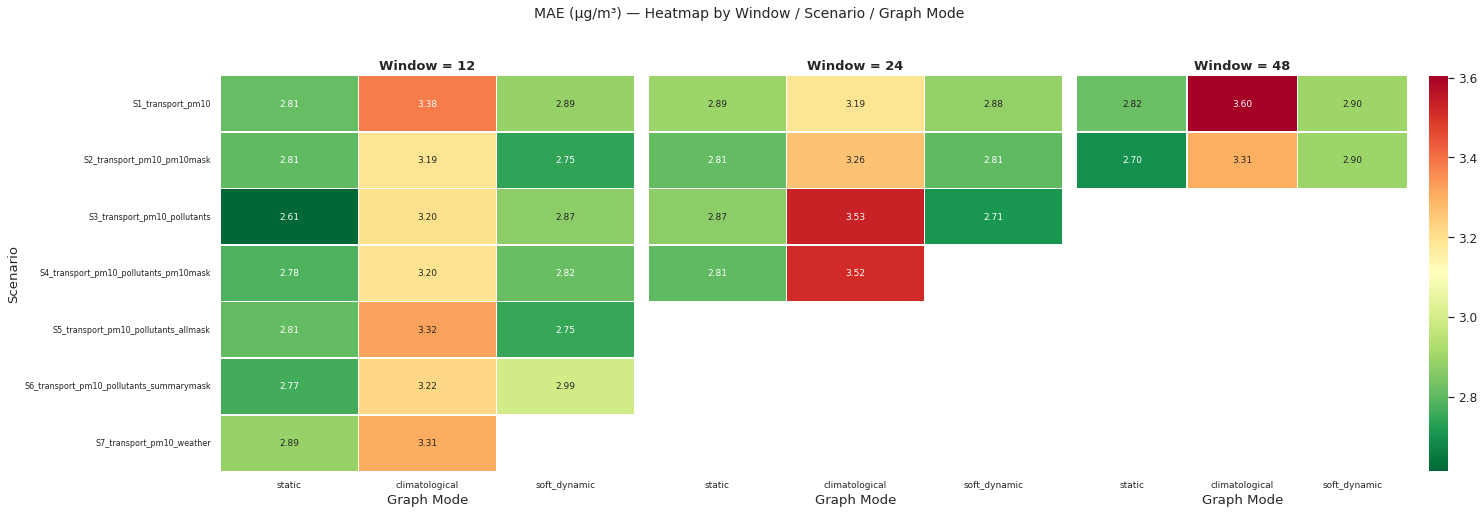

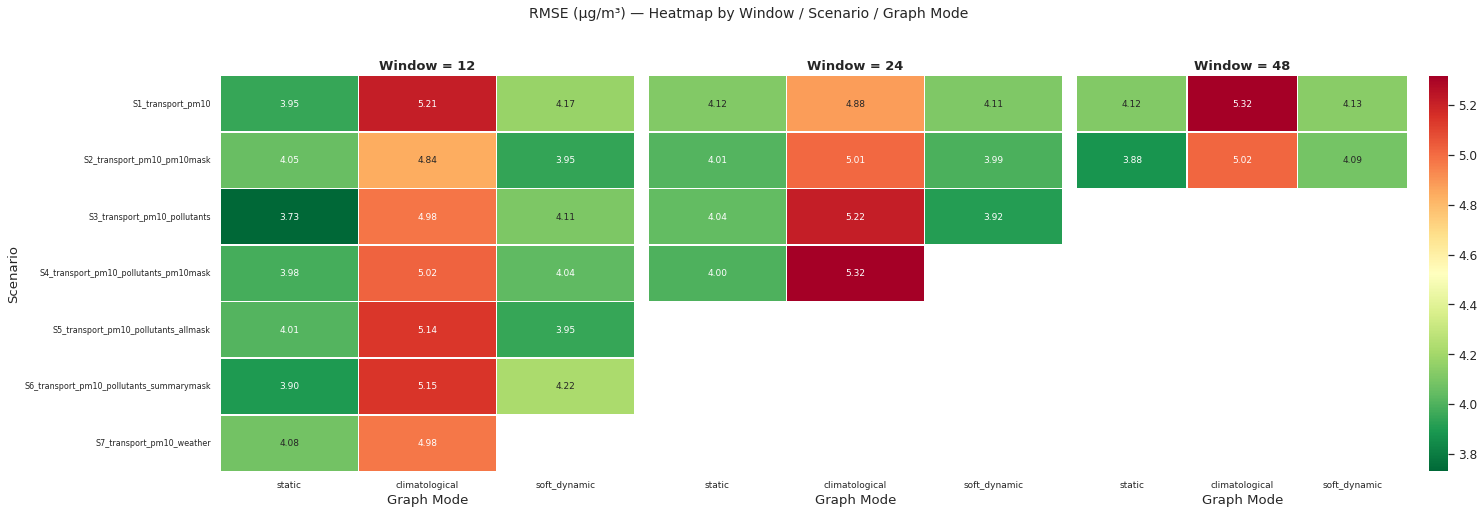

In [18]:
windows = sorted(df["window"].unique())
graph_modes = ["static", "climatological", "soft_dynamic"]
scenarios_ordered = (
    df.sort_values("s_num")["scenario"].unique().tolist()
)

for metric, label in [("mae", "MAE (µg/m³)"), ("rmse", "RMSE (µg/m³)")]:
    fig, axes = plt.subplots(1, len(windows), figsize=(7 * len(windows), 7), sharey=True)
    if len(windows) == 1:
        axes = [axes]

    vmin = df[metric].min()
    vmax = df[metric].max()

    for ax, w in zip(axes, windows):
        sub = df[df["window"] == w]
        pivot = sub.pivot_table(index="scenario", columns="graph_mode", values=metric)
        pivot = pivot.reindex(index=scenarios_ordered)
        pivot = pivot.reindex(columns=[m for m in graph_modes if m in pivot.columns])

        sns.heatmap(
            pivot, ax=ax, annot=True, fmt=".2f", cmap="RdYlGn_r",
            vmin=vmin, vmax=vmax, linewidths=0.5, cbar=(ax == axes[-1]),
            annot_kws={"size": 9},
        )
        ax.set_title(f"Window = {w}", fontsize=13, fontweight="bold")
        ax.set_xlabel("Graph Mode")
        ax.set_ylabel("Scenario" if ax == axes[0] else "")
        ax.tick_params(axis="x", labelsize=9)
        ax.tick_params(axis="y", labelsize=8)

    fig.suptitle(f"{label} — Heatmap by Window / Scenario / Graph Mode", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

---
## 3. 시나리오별 최고 성능 (전 윈도우·모드 통합 Best)

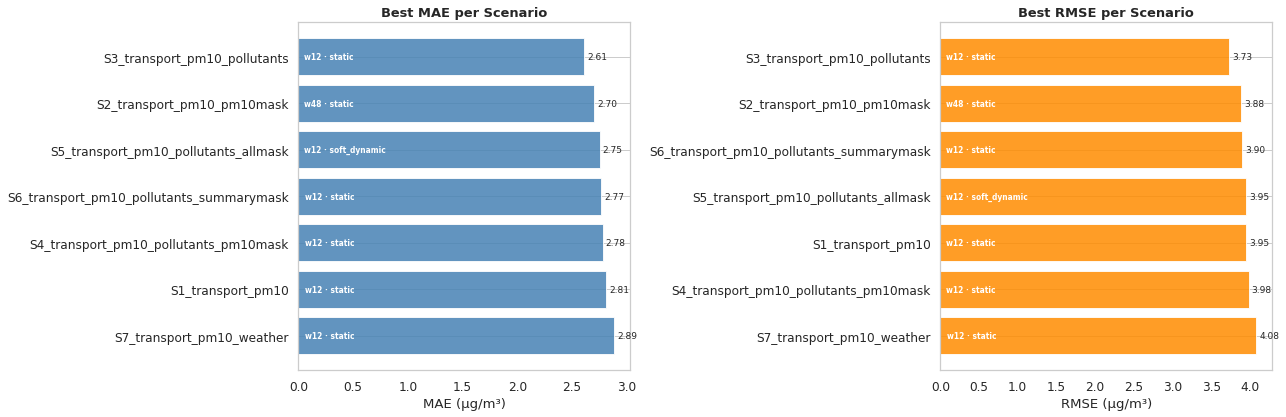

                                 scenario  window    graph_mode       mae      rmse
             S3_transport_pm10_pollutants      12        static  2.614395  3.730521
               S2_transport_pm10_pm10mask      48        static  2.703185  3.884380
     S5_transport_pm10_pollutants_allmask      12  soft_dynamic  2.753255  3.952640
 S6_transport_pm10_pollutants_summarymask      12        static  2.767203  3.899692
    S4_transport_pm10_pollutants_pm10mask      12        static  2.781022  3.981693
                        S1_transport_pm10      12        static  2.812321  3.953211
                S7_transport_pm10_weather      12        static  2.888531  4.081505


In [19]:
best_per_scenario = (
    df.loc[df.groupby("scenario")["mae"].idxmin()]
    .sort_values("mae")
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, metric, color in [
    (axes[0], "mae",  "steelblue"),
    (axes[1], "rmse", "darkorange"),
]:
    tmp = df.loc[df.groupby("scenario")[metric].idxmin()].sort_values(metric)
    bars = ax.barh(tmp["scenario"], tmp[metric], color=color, alpha=0.85)

    # 값 라벨 + best window/mode 주석
    for bar, (_, row) in zip(bars, tmp.iterrows()):
        w_bar = bar.get_width()
        ax.text(
            w_bar + w_bar * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{w_bar:.2f}", va="center", ha="left", fontsize=9,
        )
        ax.text(
            w_bar * 0.02, bar.get_y() + bar.get_height() / 2,
            f"w{row['window']} · {row['graph_mode']}",
            va="center", ha="left", fontsize=7.5, color="white", fontweight="bold",
        )

    ax.set_xlabel(f"{metric.upper()} (µg/m³)")
    ax.set_title(f"Best {metric.upper()} per Scenario", fontsize=13, fontweight="bold")
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.4)

plt.tight_layout()
plt.show()

print(best_per_scenario[["scenario", "window", "graph_mode", "mae", "rmse"]].to_string(index=False))

---
## 4. 그래프 모드별 성능 비교

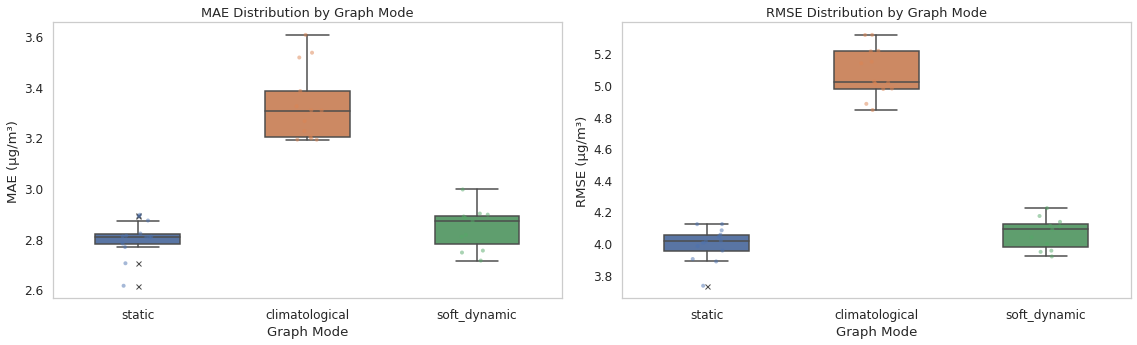

                  mae                 rmse              
                 mean    std    min   mean    std    min
graph_mode                                              
climatological  3.326  0.143  3.191  5.084  0.155  4.843
soft_dynamic    2.842  0.083  2.714  4.062  0.100  3.916
static          2.799  0.075  2.614  3.992  0.107  3.731


In [20]:
palette = {"static": "#4C72B0", "climatological": "#DD8452", "soft_dynamic": "#55A868"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric in [(axes[0], "mae"), (axes[1], "rmse")]:
    sns.boxplot(
        data=df, x="graph_mode", y=metric, palette=palette,
        order=["static", "climatological", "soft_dynamic"], ax=ax,
        width=0.5, flierprops={"marker": "x", "markersize": 5},
    )
    # 개별 점 오버레이
    sns.stripplot(
        data=df, x="graph_mode", y=metric, palette=palette,
        order=["static", "climatological", "soft_dynamic"], ax=ax,
        size=4, jitter=True, alpha=0.5, dodge=False,
    )
    ax.set_xlabel("Graph Mode")
    ax.set_ylabel(f"{metric.upper()} (µg/m³)")
    ax.set_title(f"{metric.upper()} Distribution by Graph Mode", fontsize=13)
    ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.show()

# 모드별 평균 통계
print(df.groupby("graph_mode")[["mae", "rmse"]].agg(["mean", "std", "min"]).round(3))

---
## 5. 윈도우 크기 효과 분석

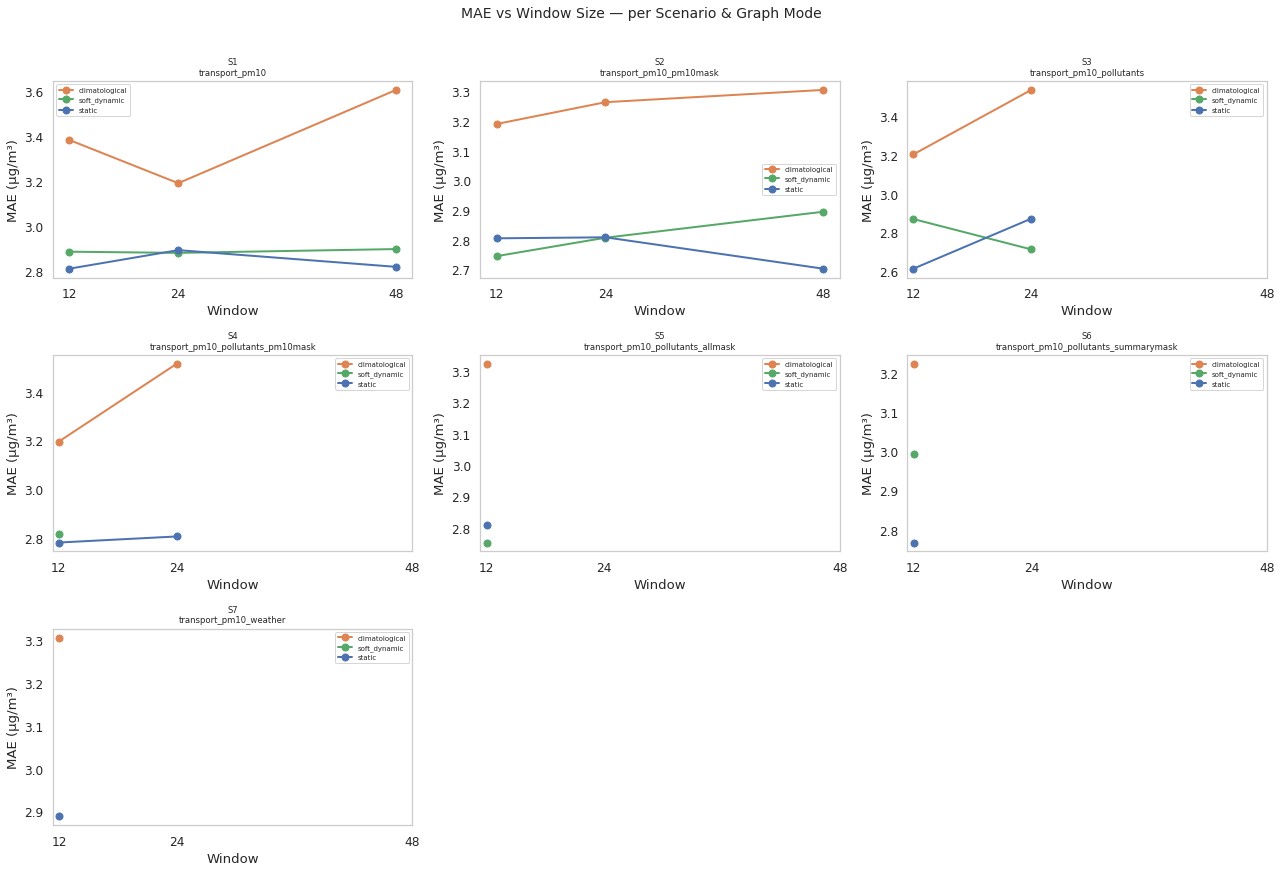

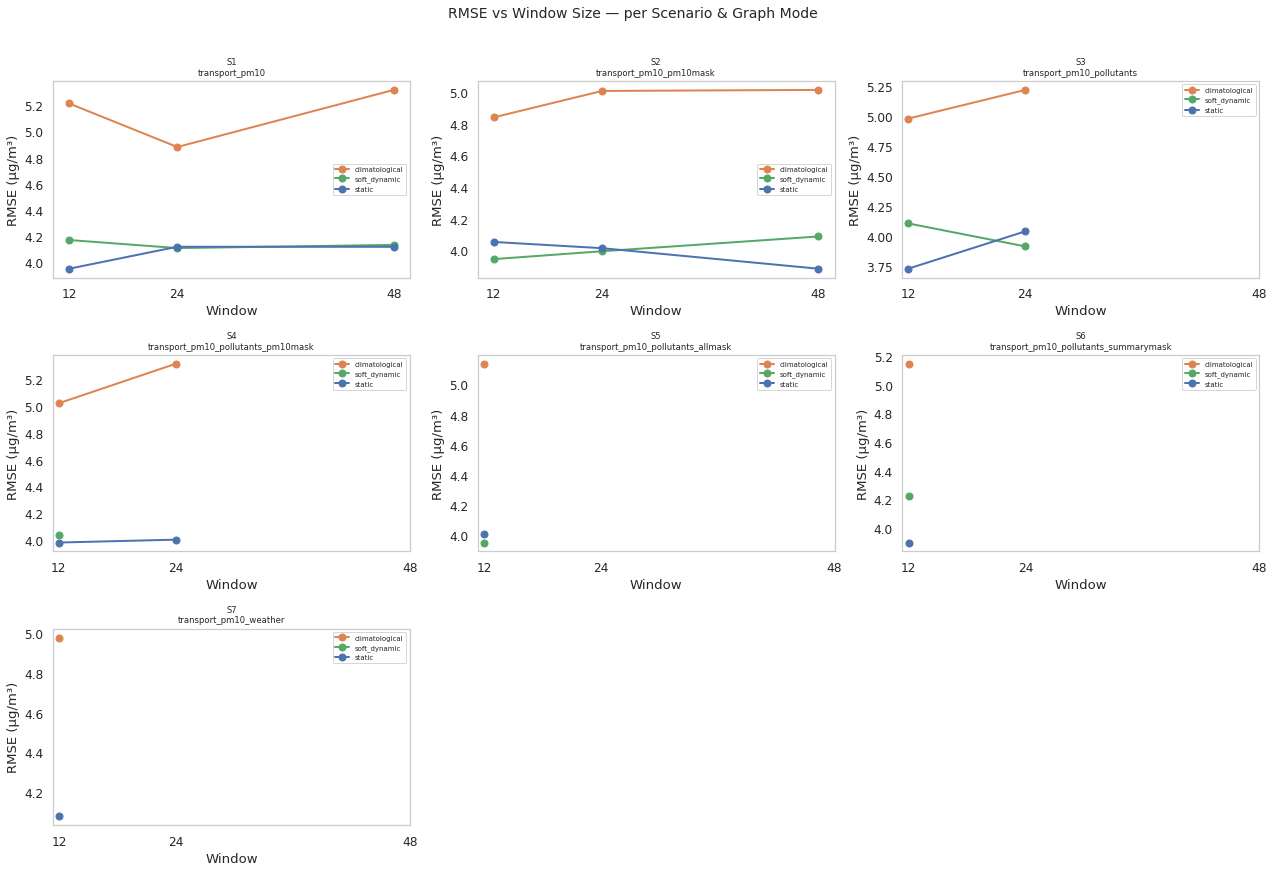


윈도우별 전체 평균
          mae          rmse       
         mean    std   mean    std
window                            
12      2.969  0.236  4.374  0.521
24      3.026  0.297  4.421  0.557
48      3.038  0.344  4.427  0.588


In [21]:
# 5-A. 윈도우 × 시나리오 — 그래프 모드별 라인 플롯
scenarios_available = df["scenario"].unique()
n_scen = len(scenarios_available)
ncols = 3
nrows = (n_scen + ncols - 1) // ncols

for metric, ylabel in [("mae", "MAE (µg/m³)"), ("rmse", "RMSE (µg/m³)")]:
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharey=False)
    axes_flat = axes.flatten()

    for idx, scen in enumerate(sorted(scenarios_available, key=lambda s: int(s.split("_")[0][1:]))):
        ax = axes_flat[idx]
        sub = df[df["scenario"] == scen].sort_values("window")
        for mode, grp in sub.groupby("graph_mode"):
            ax.plot(
                grp["window"], grp[metric],
                marker="o", label=mode, color=palette.get(str(mode)),
                linewidth=2, markersize=7,
            )
        ax.set_title(scen.replace("_", "\n", 1), fontsize=8.5)
        ax.set_xticks(sorted(df["window"].unique()))
        ax.set_xlabel("Window")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.35)
        ax.legend(fontsize=7)

    for idx in range(n_scen, len(axes_flat)):
        axes_flat[idx].set_visible(False)

    fig.suptitle(f"{metric.upper()} vs Window Size — per Scenario & Graph Mode", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

# 5-B. 윈도우별 전체 평균
window_avg = df.groupby("window")[["mae", "rmse"]].agg(["mean", "std"]).round(3)
print("\n윈도우별 전체 평균")
print(window_avg)

---
## 6. 학습 Loss Curve

In [22]:
# 모든 loss_history.csv 수집
loss_records = []
for path in glob.glob(os.path.join(CHECKPOINT_ROOT, "**", "loss_history.csv"), recursive=True):
    try:
        tmp = pd.read_csv(path)
    except Exception:
        continue
    parts = path.replace("\\", "/").split("/")
    # checkpoints/window_W/scenario/graph_mode/loss_history.csv
    try:
        w        = int(parts[-4].replace("window_", ""))
        scenario = parts[-3]
        mode     = parts[-2]
    except (IndexError, ValueError):
        continue
    tmp["window"]     = w
    tmp["scenario"]   = scenario
    tmp["graph_mode"] = mode
    tmp["label"]      = f"w{w} · {scenario[:25]} · {mode}"
    loss_records.append(tmp)

df_loss = pd.concat(loss_records, ignore_index=True) if loss_records else pd.DataFrame()
print(f"Loss curve 보유 실험: {len(loss_records)}개")

Loss curve 보유 실험: 37개


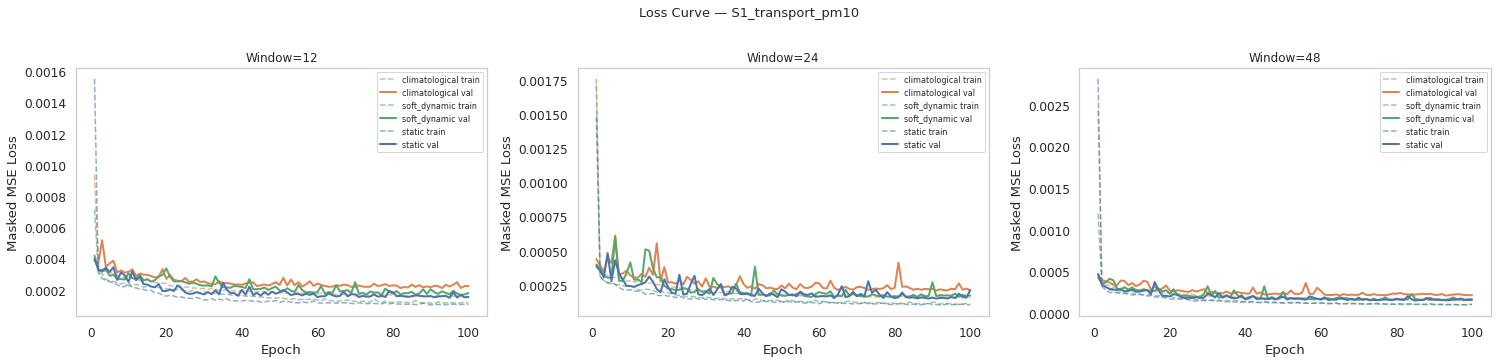

In [23]:
# 6-A. 시나리오 S1 — 모든 window × mode 학습 곡선
TARGET_SCENARIO = "S1_transport_pm10"   # ← 원하는 시나리오로 변경 가능

sub_loss = df_loss[df_loss["scenario"] == TARGET_SCENARIO] if not df_loss.empty else pd.DataFrame()

if sub_loss.empty:
    print(f"{TARGET_SCENARIO}의 loss_history.csv를 찾을 수 없습니다.")
else:
    windows_s1 = sorted(sub_loss["window"].unique())
    fig, axes = plt.subplots(1, len(windows_s1), figsize=(7 * len(windows_s1), 5), sharey=False)
    if len(windows_s1) == 1:
        axes = [axes]

    for ax, w in zip(axes, windows_s1):
        sub_w = sub_loss[sub_loss["window"] == w]
        for mode, grp in sub_w.groupby("graph_mode"):
            ax.plot(grp["epoch"], grp["train_loss"], linestyle="--", alpha=0.6,
                    color=palette.get(str(mode)), label=f"{mode} train")
            ax.plot(grp["epoch"], grp["val_loss"], linestyle="-", linewidth=2,
                    color=palette.get(str(mode)), label=f"{mode} val")
        ax.set_title(f"Window={w}", fontsize=12)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Masked MSE Loss")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.35)

    fig.suptitle(f"Loss Curve — {TARGET_SCENARIO}", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

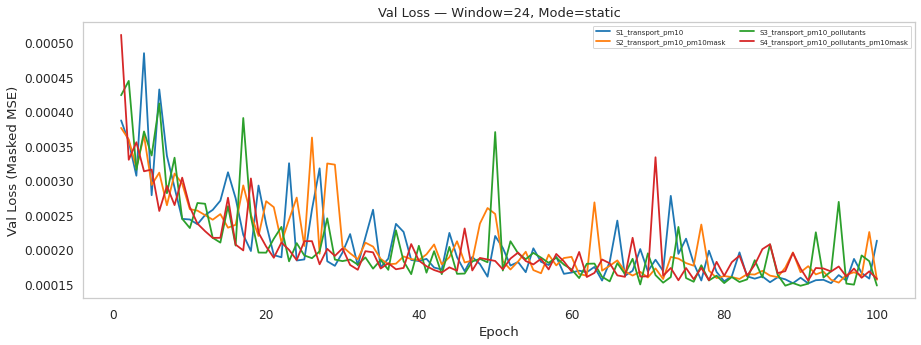

In [24]:
# 6-B. window=24, static — 전 시나리오 validation loss 비교
TARGET_WINDOW = 24
TARGET_MODE   = "static"

sub_loss2 = (
    df_loss[
        (df_loss["window"] == TARGET_WINDOW) &
        (df_loss["graph_mode"] == TARGET_MODE)
    ]
    if not df_loss.empty else pd.DataFrame()
)

if sub_loss2.empty:
    print(f"w={TARGET_WINDOW}, mode={TARGET_MODE} 데이터 없음")
else:
    fig, ax = plt.subplots(figsize=(13, 5))
    cmap = plt.get_cmap("tab10")
    scenarios_sub = sorted(sub_loss2["scenario"].unique(), key=lambda s: int(s.split("_")[0][1:]))
    for i, scen in enumerate(scenarios_sub):
        grp = sub_loss2[sub_loss2["scenario"] == scen]
        ax.plot(grp["epoch"], grp["val_loss"], linewidth=1.8, color=cmap(i), label=scen)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Val Loss (Masked MSE)")
    ax.set_title(f"Val Loss — Window={TARGET_WINDOW}, Mode={TARGET_MODE}", fontsize=13)
    ax.legend(fontsize=7, ncol=2, loc="upper right")
    ax.grid(alpha=0.35)
    plt.tight_layout()
    plt.show()

---
## 7. 전체 랭킹 테이블

In [25]:
# MAE 오름차순 전체 랭킹
ranking = (
    df[["window", "scenario", "graph_mode", "mae", "rmse", "n_features", "elapsed_min"]]
    .sort_values("mae")
    .reset_index(drop=True)
)
ranking.index += 1
ranking.index.name = "Rank"

display_cols = {"window": "Window", "scenario": "Scenario",
                "graph_mode": "Graph Mode", "mae": "MAE",
                "rmse": "RMSE", "n_features": "#Features", "elapsed_min": "Time(min)"}
ranking = ranking.rename(columns=display_cols)

ranking.style \
    .format({"MAE": "{:.3f}", "RMSE": "{:.3f}", "Time(min)": "{:.1f}"}) \
    .background_gradient(subset=["MAE"],  cmap="RdYlGn_r") \
    .background_gradient(subset=["RMSE"], cmap="RdYlGn_r") \
    .set_caption("전체 랭킹 (MAE 오름차순)")

,Window,Scenario,Graph Mode,MAE,RMSE,#Features,Time(min)
Rank,,,,,,,
1,12,S3_transport_pm10_pollutants,static,2.614,3.731,9,44.4
2,48,S2_transport_pm10_pm10mask,static,2.703,3.884,5,149.2
3,24,S3_transport_pm10_pollutants,soft_dynamic,2.714,3.916,9,94.3
4,12,S2_transport_pm10_pm10mask,soft_dynamic,2.745,3.945,5,45.1
5,12,S5_transport_pm10_pollutants_allmask,soft_dynamic,2.753,3.953,9,55.3
6,12,S6_transport_pm10_pollutants_summarymask,static,2.767,3.900,9,49.3
7,12,S4_transport_pm10_pollutants_pm10mask,static,2.781,3.982,9,44.3
8,12,S2_transport_pm10_pm10mask,static,2.806,4.054,5,42.7
9,24,S4_transport_pm10_pollutants_pm10mask,static,2.806,4.003,9,91.4


In [26]:
# Top-5 / Bottom-5 출력
print("=== TOP-5 (Best MAE) ===")
print(ranking.head(5).to_string())
print("\n=== BOTTOM-5 (Worst MAE) ===")
print(ranking.tail(5).to_string())

# 전체 최고
best = df.loc[df["mae"].idxmin()]
print(f"\n★ Global Best MAE: {best['mae']:.3f} µg/m³")
print(f"   → window={best['window']}, scenario={best['scenario']}, mode={best['graph_mode']}")

best_r = df.loc[df["rmse"].idxmin()]
print(f"\n★ Global Best RMSE: {best_r['rmse']:.3f} µg/m³")
print(f"   → window={best_r['window']}, scenario={best_r['scenario']}, mode={best_r['graph_mode']}")

=== TOP-5 (Best MAE) ===
      Window                              Scenario    Graph Mode       MAE      RMSE  #Features   Time(min)
Rank                                                                                                       
1         12          S3_transport_pm10_pollutants        static  2.614395  3.730521          9   44.429503
2         48            S2_transport_pm10_pm10mask        static  2.703185  3.884380          5  149.218993
3         24          S3_transport_pm10_pollutants  soft_dynamic  2.713803  3.916006          9   94.319360
4         12            S2_transport_pm10_pm10mask  soft_dynamic  2.745474  3.945152          5   45.078631
5         12  S5_transport_pm10_pollutants_allmask  soft_dynamic  2.753255  3.952640          9   55.281254

=== BOTTOM-5 (Worst MAE) ===
      Window                               Scenario      Graph Mode       MAE      RMSE  #Features   Time(min)
Rank                                                                          